Loading HPC Data from /Users/suttamchanda/Downloads/PRL_Dataset_N1000_Grid10.npz...
Data Loaded! N=1000. Global Time: 0.3s | Async Time: 0.2s
Reconstructing Physical Force Chains...
Rendering Figure 1...
Rendering Figure 2...
Rendering Figure 3...
Rendering Figure 4...
Rendering Figure 5...

All 5 PRL Figures generated and saved as PDFs!


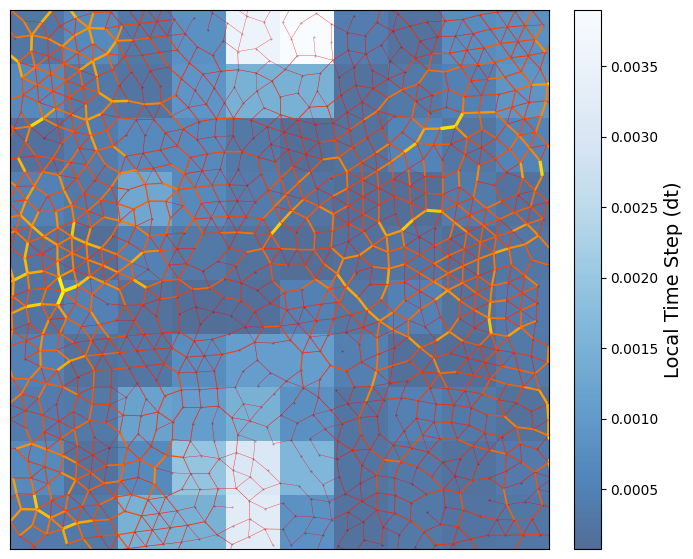

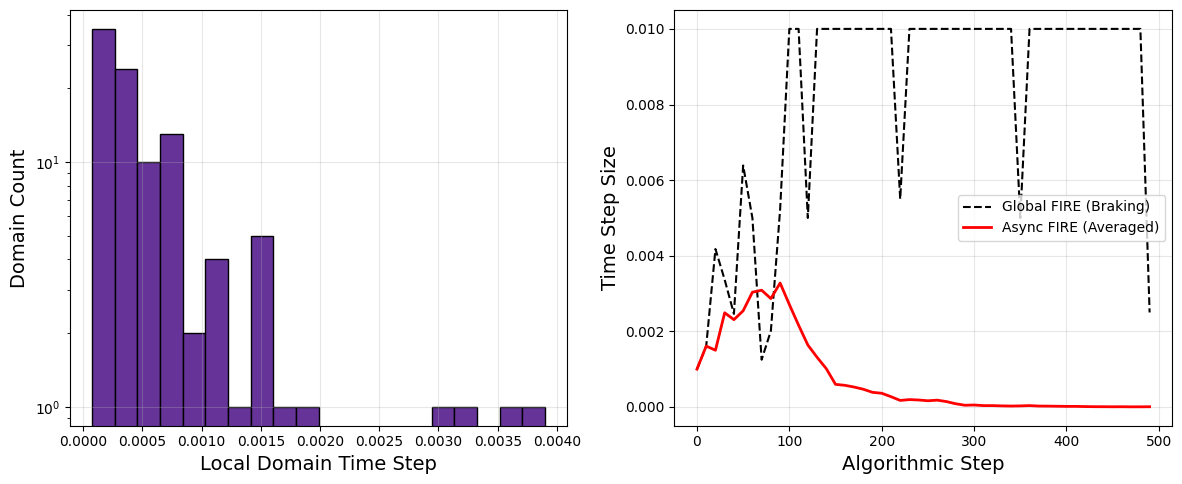

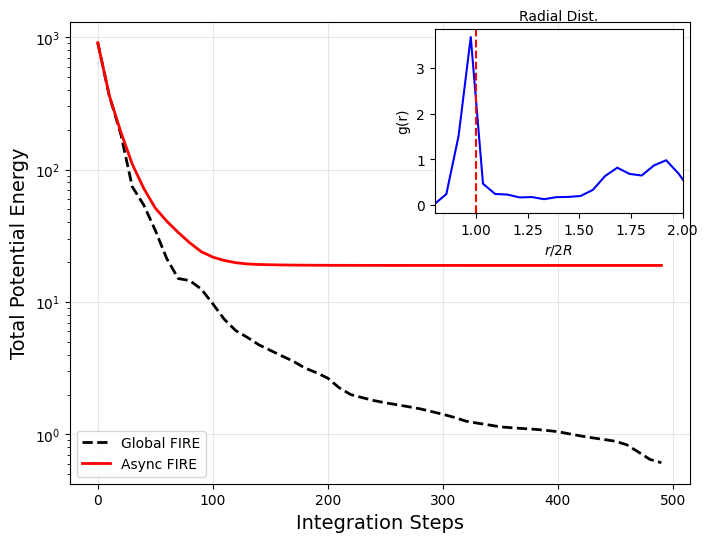

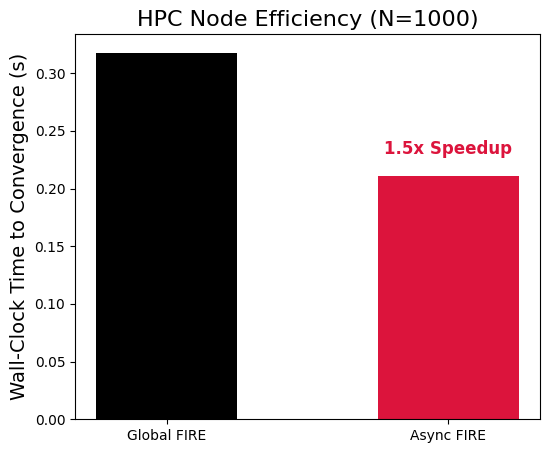

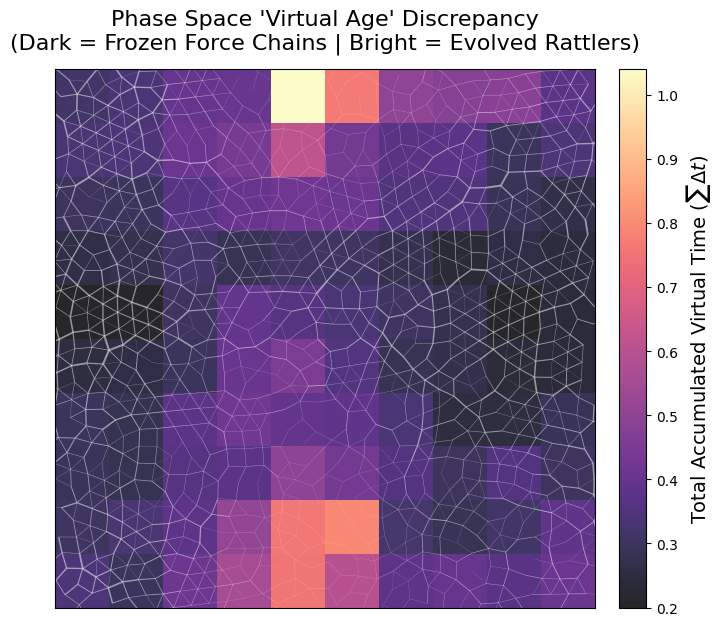

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from mpl_toolkits.axes_grid1 import inset_locator
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 18
})


filename = "/Users/suttamchanda/Downloads/PRL_Dataset_N1000_Grid10.npz"  # Change to your actual filename
print(f"Loading HPC Data from {filename}...")
data = np.load(filename)

pos_async = data['pos_async']
dt_grid_snap = data['dt_grid_snap']
e_hist_async = data['e_hist_async']
e_hist_glob = data['e_hist_glob']
dt_hist_async = data['dt_hist_async']
dt_hist_glob = data['dt_hist_glob']
time_async = float(data['time_async'])
time_glob = float(data['time_glob'])
RADIUS = float(data['radius'])
K_SPRING = float(data['k_spring'])
GRID_DIVS = int(data['grid_divs'])
N_ATOMS = int(data['n_atoms'])

# Handle the 5th plot data (Fallback if you haven't run the HPC fix yet)
if 'accumulated_dt' in data:
    accumulated_dt = data['accumulated_dt']
else:
    print("Warning: 'accumulated_dt' not found in NPZ. Using snapshot as placeholder.")
    accumulated_dt = dt_grid_snap * len(e_hist_async) * 10 

print(f"Data Loaded! N={N_ATOMS}. Global Time: {time_glob:.1f}s | Async Time: {time_async:.1f}s")

print("Reconstructing Physical Force Chains...")
cutoff = 2.0 * RADIUS
lines = []
force_mags = []
distances = []  # For g(r)

# Local O(N^2) loop (takes ~10 seconds for 25k atoms on a laptop)
for i in range(N_ATOMS):
    for j in range(i+1, N_ATOMS):
        dx_raw = pos_async[i,0] - pos_async[j,0]
        dy_raw = pos_async[i,1] - pos_async[j,1]
        dx = dx_raw - np.round(dx_raw)
        dy = dy_raw - np.round(dy_raw)
        dist = np.sqrt(dx**2 + dy**2)
        distances.append(dist)
        
        if dist < cutoff:
            lines.append([(pos_async[i,0], pos_async[i,1]), (pos_async[i,0]-dx, pos_async[i,1]-dy)])
            force_mags.append(K_SPRING * (cutoff - dist))

force_array = np.array(force_mags)
distances = np.array(distances)

print("Rendering Figure 1...")
fig1, ax1 = plt.subplots(figsize=(8, 7))

dt_grid = dt_grid_snap.reshape(GRID_DIVS, GRID_DIVS).T
heatmap1 = ax1.imshow(dt_grid, cmap='Blues_r', origin='lower', extent=[0, 1, 0, 1], alpha=0.7)
ax1.scatter(pos_async[:, 0], pos_async[:, 1], s=0.5, c='black', alpha=0.2)

if len(lines) > 0:
    lw = (force_array / np.max(force_array)) * 2.5 + 0.2
    lc = LineCollection(lines, cmap='autumn', linewidths=lw)
    lc.set_array(force_array)
    ax1.add_collection(lc)

ax1.set_xticks([]); ax1.set_yticks([])
fig1.colorbar(heatmap1, ax=ax1, fraction=0.046, pad=0.04, label="Local Time Step (dt)")
plt.savefig('Fig1_Bifurcation.pdf', bbox_inches='tight')

print("Rendering Figure 2...")
fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Histogram
ax2a.hist(dt_grid_snap, bins=20, color='rebeccapurple', edgecolor='black')
ax2a.set_yscale('log')
ax2a.set_xlabel("Local Domain Time Step")
ax2a.set_ylabel("Domain Count")
ax2a.grid(alpha=0.3)

# Panel B: Time Step Evolution
steps = np.arange(len(dt_hist_glob)) * 10
ax2b.plot(steps, dt_hist_glob, 'k--', linewidth=1.5, label='Global FIRE (Braking)')
ax2b.plot(steps, dt_hist_async, 'r-', linewidth=2, label='Async FIRE (Averaged)')
ax2b.set_xlabel("Algorithmic Step")
ax2b.set_ylabel("Time Step Size")
ax2b.legend()
ax2b.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Fig2_Dynamics.pdf', bbox_inches='tight')


print("Rendering Figure 3...")
fig3, ax3 = plt.subplots(figsize=(8, 6))

steps_e = np.arange(len(e_hist_glob)) * 10
ax3.plot(steps_e, e_hist_glob, 'k--', linewidth=2, label='Global FIRE')
ax3.plot(steps_e, e_hist_async, 'r-', linewidth=2, label='Async FIRE')
ax3.set_yscale('log')
ax3.set_xlabel("Integration Steps")
ax3.set_ylabel("Total Potential Energy")
ax3.legend(loc='lower left')
ax3.grid(alpha=0.3)

# Inset: g(r) Plot
axins = inset_locator.inset_axes(ax3, width="40%", height="40%", loc='upper right')
dr = 0.002
r_max = 5 * RADIUS
bins = np.arange(0, r_max, dr)
hist, _ = np.histogram(distances, bins=bins)
r_centers = (bins[1:] + bins[:-1]) / 2.0
rho = N_ATOMS / (1.0**2)
ideal = 2 * np.pi * r_centers * dr * rho * N_ATOMS
g_r = hist / ideal

axins.plot(r_centers / (2*RADIUS), g_r, 'b-', linewidth=1.5)
axins.axvline(1.0, color='r', linestyle='--')
axins.set_xlim(0.8, 2.0)
axins.set_xlabel("$r / 2R$", fontsize=10)
axins.set_ylabel("g(r)", fontsize=10)
axins.set_title("Radial Dist.", fontsize=10)
plt.savefig('Fig3_Energy_GR.pdf', bbox_inches='tight')

print("Rendering Figure 4...")
fig4, ax4 = plt.subplots(figsize=(6, 5))
labels = ['Global FIRE', 'Async FIRE']
times = [time_glob, time_async]
colors = ['black', 'crimson']

bars = ax4.bar(labels, times, color=colors, width=0.5)
ax4.set_ylabel("Wall-Clock Time to Convergence (s)")
ax4.set_title(f"HPC Node Efficiency (N={N_ATOMS})")

# Add the speedup multiplier as text
speedup = time_glob / time_async
ax4.text(1, time_async + (time_glob*0.05), f"{speedup:.1f}x Speedup", ha='center', va='bottom', fontweight='bold', color='crimson')

plt.savefig('Fig4_Speedup.pdf', bbox_inches='tight')

print("Rendering Figure 5...")
fig5, ax5 = plt.subplots(figsize=(8, 7))

age_grid = accumulated_dt.reshape(GRID_DIVS, GRID_DIVS).T
# We use 'magma' to represent total elapsed virtual time
heatmap5 = ax5.imshow(age_grid, cmap='magma', origin='lower', extent=[0, 1, 0, 1], alpha=0.85)

if len(lines) > 0:
    # Plot forces in subtle white to show correlation
    lw = (force_array / np.max(force_array)) * 1.5 + 0.1
    lc5 = LineCollection(lines, colors='white', linewidths=lw, alpha=0.5)
    ax5.add_collection(lc5)

ax5.set_xticks([]); ax5.set_yticks([])
fig5.colorbar(heatmap5, ax=ax5, fraction=0.046, pad=0.04, label=r"Total Accumulated Virtual Time ($\sum \Delta t$)")
ax5.set_title("Phase Space 'Virtual Age' Discrepancy\n(Dark = Frozen Force Chains | Bright = Evolved Rattlers)", pad=15)

plt.savefig('Fig5_Virtual_Age.pdf', bbox_inches='tight')
print("\nAll 5 PRL Figures generated and saved as PDFs!")
plt.show()